I will be looking at SVR

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv("energydata_complete.csv")  
#pre processing

## this is converting the date to pure numerical values. regression models need this
data['date'] = pd.to_datetime(data['date'])

data['hour'] = data['date'].dt.hour
data['day_of_week'] = data['date'].dt.dayofweek

## drop unecessary data, rv1 and rv2 are declared as random variables in the dataset description
data = data.drop(columns=['date','rv1','rv2'])





Looking at any missing values (result: there are none)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non-null  float64
 19  RH_9

Now lets run standard SVR with unmodified/basic hyperparameters. Also plotting results

MSE: 5171.495110227215
R2: 0.4832169447027779


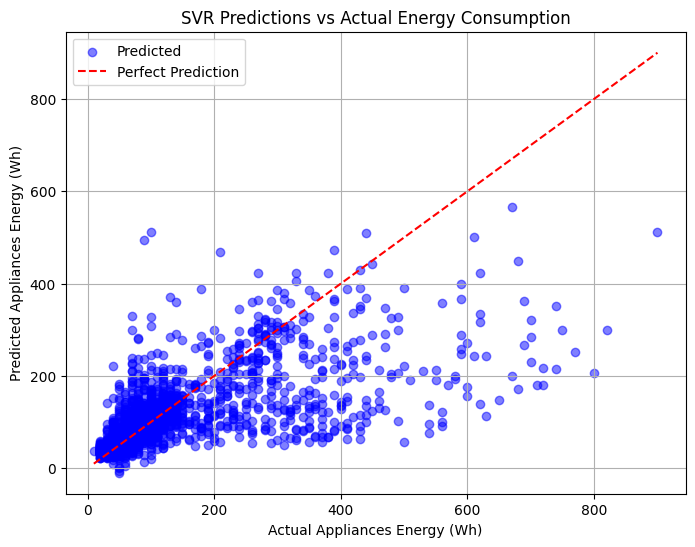

In [16]:
X = data.drop(columns=['Appliances']) #indepandant features
y = data['Appliances']  #target 
# test train split for the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Both target and independant features need to be scaled /n
# because if features and targets are on different scales, the optimization can be ill-conditioned.
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = svr.predict(X_test_scaled)
# Convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)
plt.figure(figsize=(8,6))

#plot results
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted')

#reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Appliances Energy (Wh)')
plt.ylabel('Predicted Appliances Energy (Wh)')
plt.title('SVR Predictions vs Actual Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()


